# Etap 2 — Klasyczny ML: Random Forest na patchach 5×5

## 1. Przygotowanie środowiska

In [11]:
import sys, json, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from src import io_utils, metrics, visualize, features, classical_ml
from src.config import (
    TRAIN_IMAGES, TEST_IMAGES, RANDOM_SEED, PATCH_SIZE,
    MODELS_DIR, RESULTS_DIR,
)
rng = np.random.default_rng(RANDOM_SEED)

print(f'Train images ({len(TRAIN_IMAGES)}): pierwsze 5 = {TRAIN_IMAGES[:5]}')
print(f'Test images  ({len(TEST_IMAGES)}): {TEST_IMAGES}')
print(f'Patch size:  {PATCH_SIZE}×{PATCH_SIZE}')
print(f'N features:  {features.N_FEATURES}')

Train images (39): pierwsze 5 = ['01_h', '02_h', '03_h', '04_h', '05_h']
Test images  (6): ['14_h', '15_h', '14_dr', '15_dr', '14_g', '15_g']
Patch size:  5×5
N features:  24


## 2. Budowa zbioru uczącego

Sampling zbalansowany (50% naczynia / 50% tło) wewnątrz FOV. Po `N_SAMPLES_PER_IMAGE` punktów z każdego z pierwszych `N_TRAIN_IMAGES` obrazów.

In [12]:
N_TRAIN_IMAGES = 10
N_SAMPLES_PER_IMAGE = 5000
train_subset = TRAIN_IMAGES[:N_TRAIN_IMAGES]
print(f'Używamy {len(train_subset)} obrazów: {train_subset}')

t0 = time.time()
X, y = features.build_dataset(
    train_subset,
    loader=io_utils.load_triplet,
    n_samples_per_image=N_SAMPLES_PER_IMAGE,
    patch_size=PATCH_SIZE,
    seed=RANDOM_SEED,
)
print(f'\nZbiór danych zebrany w {time.time()-t0:.1f} s')
print(f'X shape: {X.shape}, dtype={X.dtype}')
print(f'y shape: {y.shape}, dtype={y.dtype}')
print(f'Rozkład klas: vessels={int((y==1).sum())}, background={int((y==0).sum())}')

Używamy 10 obrazów: ['01_h', '02_h', '03_h', '04_h', '05_h', '06_h', '07_h', '08_h', '09_h', '10_h']


Build dataset: 100%|██████████| 10/10 [00:02<00:00,  4.01it/s]


Zbiór danych zebrany w 2.5 s
X shape: (50000, 24), dtype=float32
y shape: (50000,), dtype=uint8
Rozkład klas: vessels=25000, background=25000


## 3. Hold-out wewnątrz zbioru uczącego

Podział stratyfikowany na train/val (2/3 : 1/3).

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=1/3, stratify=y, random_state=RANDOM_SEED,
)
print(f'train: X={X_train.shape}  y vessels={(y_train==1).sum()}  bg={(y_train==0).sum()}')
print(f'val:   X={X_val.shape}  y vessels={(y_val==1).sum()}  bg={(y_val==0).sum()}')

train: X=(33333, 24)  y vessels=16667  bg=16666
val:   X=(16667, 24)  y vessels=8333  bg=8334


## 4. Uczenie Random Forest

### 4.1 Bazowy pipeline

In [14]:
pipe = classical_ml.make_pipeline(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

### 4.2 GridSearchCV

In [15]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 20],
}
gs = GridSearchCV(pipe, param_grid, scoring='balanced_accuracy', cv=3, n_jobs=-1, verbose=2)
gs.fit(X_train, y_train)
print('Best params:', gs.best_params_)
print('Best CV balanced accuracy:', gs.best_score_)
pipe = gs.best_estimator_

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ............rf__max_depth=None, rf__n_estimators=50; total time=   3.7s
[CV] END ............rf__max_depth=None, rf__n_estimators=50; total time=   3.7s
[CV] END ............rf__max_depth=None, rf__n_estimators=50; total time=   3.8s
[CV] END ...........rf__max_depth=None, rf__n_estimators=100; total time=   6.9s
[CV] END ...........rf__max_depth=None, rf__n_estimators=100; total time=   6.9s
[CV] END ..............rf__max_depth=20, rf__n_estimators=50; total time=   3.3s
[CV] END ...........rf__max_depth=None, rf__n_estimators=100; total time=   7.0s
[CV] END ..............rf__max_depth=20, rf__n_estimators=50; total time=   3.4s
[CV] END ..............rf__max_depth=20, rf__n_estimators=50; total time=   3.5s
[CV] END ...........rf__max_depth=None, rf__n_estimators=200; total time=  13.8s
[CV] END .............rf__max_depth=20, rf__n_estimators=100; total time=   7.0s
[CV] END ...........rf__max_depth=None, rf__n_est

## 5. Walidacja na zbiorze val

In [16]:
y_val_pred = pipe.predict(X_val)

from sklearn.metrics import confusion_matrix, classification_report
cm_val = confusion_matrix(y_val, y_val_pred, labels=[0, 1])
tn, fp, fn, tp = cm_val.ravel()
sens = tp / (tp + fn) if (tp + fn) else 0.0
spec = tn / (tn + fp) if (tn + fp) else 0.0
acc  = (tp + tn) / cm_val.sum()
g_mean = float(np.sqrt(sens * spec))
print(f'Validation: acc={acc:.4f}  sens={sens:.4f}  spec={spec:.4f}  g_mean={g_mean:.4f}')
print()
print(classification_report(y_val, y_val_pred, target_names=['background', 'vessel']))

Validation: acc=0.8772  sens=0.8523  spec=0.9022  g_mean=0.8769

              precision    recall  f1-score   support

  background       0.86      0.90      0.88      8334
      vessel       0.90      0.85      0.87      8333

    accuracy                           0.88     16667
   macro avg       0.88      0.88      0.88     16667
weighted avg       0.88      0.88      0.88     16667



## 6. Predykcja na obrazach testowych

Sliding window z `stride=2` na tych samych `TEST_IMAGES`, co w etapie 1.

In [17]:
STRIDE = 2
per_image = {}
predictions = {}
for image_id in TEST_IMAGES:
    img, gt, fv = io_utils.load_triplet(image_id)
    t0 = time.time()
    pred = classical_ml.predict_mask(
        pipe, img, fv, patch_size=PATCH_SIZE, stride=STRIDE, progress=False,
    )
    m = metrics.compute_metrics(pred, gt, fv)
    per_image[image_id] = m
    predictions[image_id] = (img, gt, fv, pred)
    print(f'{image_id}: {time.time()-t0:5.1f}s  '
          f'acc={m["accuracy"]:.4f}  sens={m["sensitivity"]:.4f}  '
          f'spec={m["specificity"]:.4f}  g_mean={m["g_mean"]:.4f}')

agg = metrics.aggregate(list(per_image.values()))
print('\n=== Statystyka zbiorcza (mean ± std) ===')
for k in ['accuracy', 'sensitivity', 'specificity', 'g_mean', 'balanced_accuracy']:
    print(f'  {k:20s} = {agg[k+"_mean"]:.4f} ± {agg[k+"_std"]:.4f}')

14_h:  15.5s  acc=0.8890  sens=0.7817  spec=0.9014  g_mean=0.8394
15_h:  16.1s  acc=0.9245  sens=0.6709  spec=0.9504  g_mean=0.7985
14_dr:  16.6s  acc=0.8565  sens=0.7780  spec=0.8642  g_mean=0.8200
15_dr:  14.6s  acc=0.8394  sens=0.8424  spec=0.8391  g_mean=0.8408
14_g:  15.2s  acc=0.9107  sens=0.6822  spec=0.9315  g_mean=0.7972
15_g:  14.7s  acc=0.8355  sens=0.8432  spec=0.8347  g_mean=0.8389

=== Statystyka zbiorcza (mean ± std) ===
  accuracy             = 0.8759 ± 0.0377
  sensitivity          = 0.7664 ± 0.0752
  specificity          = 0.8869 ± 0.0485
  g_mean               = 0.8225 ± 0.0206
  balanced_accuracy    = 0.8267 ± 0.0158


### 6.1 Tabela wyników

In [18]:
df = pd.DataFrame(per_image).T[
    ['accuracy', 'sensitivity', 'specificity', 'precision', 'g_mean', 'balanced_accuracy']
]
df.loc['MEAN'] = df.mean()
df.loc['STD']  = df.iloc[:-1].std()
df.round(4)

,accuracy,sensitivity,specificity,precision,g_mean,balanced_accuracy
14_h,0.8890,0.7817,0.9014,0.4774,0.8394,0.8416
15_h,0.9245,0.6709,0.9504,0.5806,0.7985,0.8107
14_dr,0.8565,0.7780,0.8642,0.3628,0.8200,0.8211
15_dr,0.8394,0.8424,0.8391,0.3052,0.8408,0.8408
14_g,0.9107,0.6822,0.9315,0.4760,0.7972,0.8069
15_g,0.8355,0.8432,0.8347,0.3262,0.8389,0.8390
MEAN,0.8759,0.7664,0.8869,0.4214,0.8225,0.8267
STD,0.0377,0.0752,0.0485,0.1072,0.0206,0.0158


### 6.2 Ważność cech (feature importance)

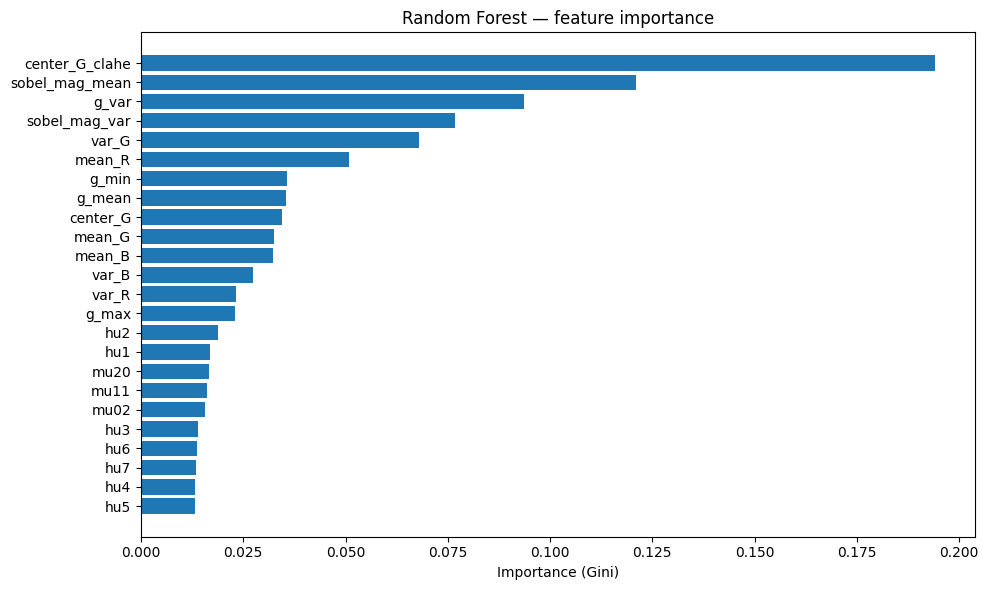

In [19]:
feature_names = (
    ['mean_R', 'mean_G', 'mean_B', 'var_R', 'var_G', 'var_B',
     'center_G', 'center_G_clahe',
     'g_mean', 'g_var', 'g_min', 'g_max',
     'hu1', 'hu2', 'hu3', 'hu4', 'hu5', 'hu6', 'hu7',
     'mu20', 'mu02', 'mu11',
     'sobel_mag_mean', 'sobel_mag_var']
)
assert len(feature_names) == features.N_FEATURES, 'feature_names mismatch'

importances = pipe.named_steps['rf'].feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(importances))[::-1], importances[order])
ax.set_yticks(range(len(importances))[::-1])
ax.set_yticklabels([feature_names[i] for i in order])
ax.set_xlabel('Importance (Gini)')
ax.set_title('Random Forest — feature importance')
fig.tight_layout(); plt.show()

### 6.3 Porównanie wizualne

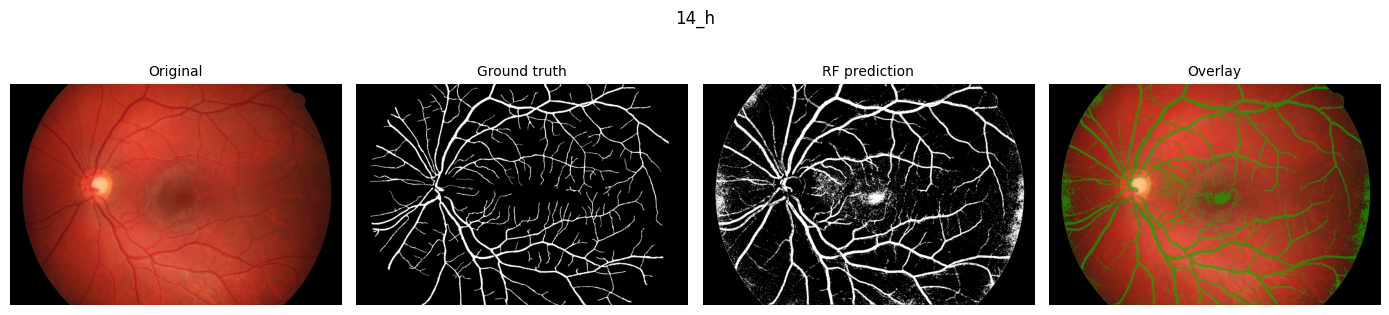

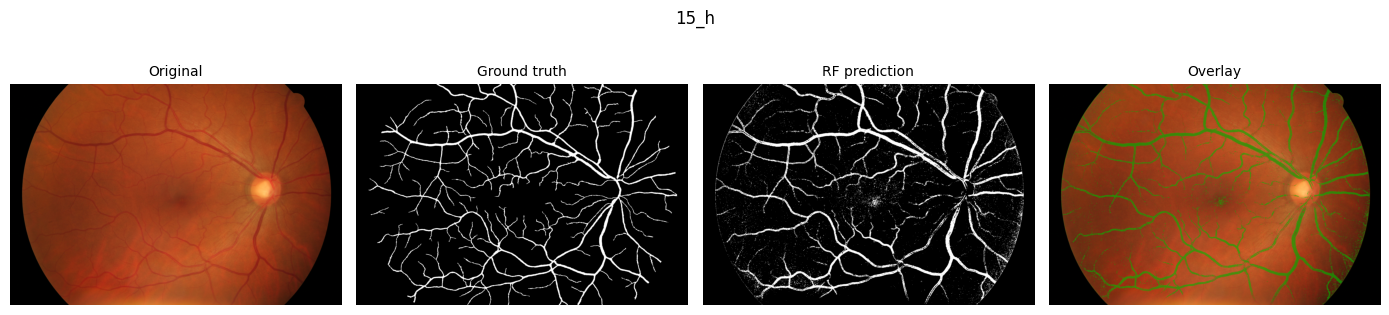

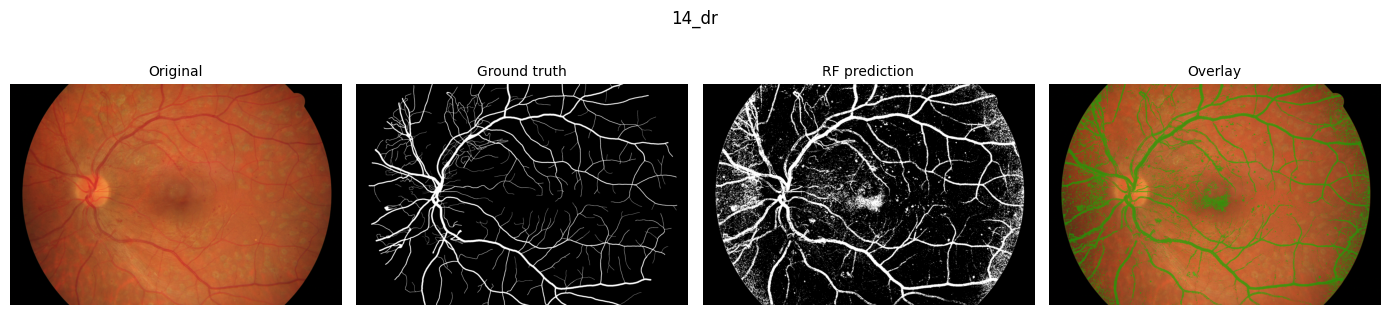

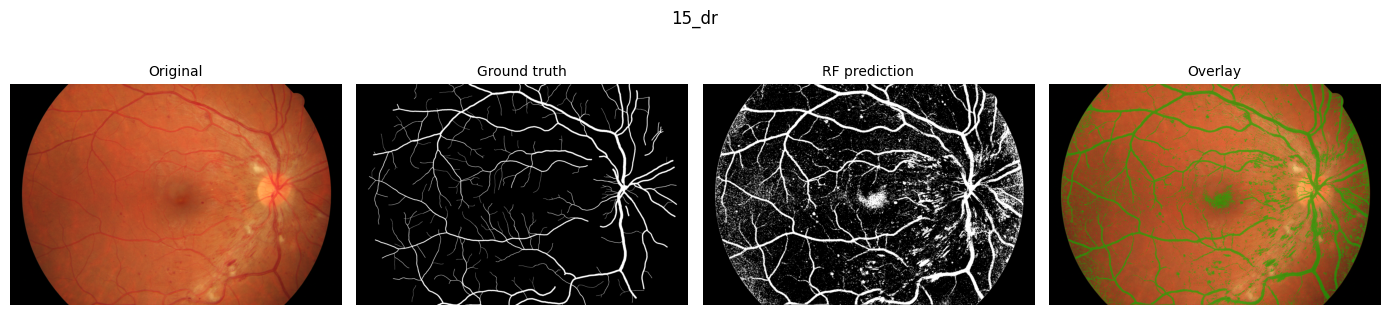

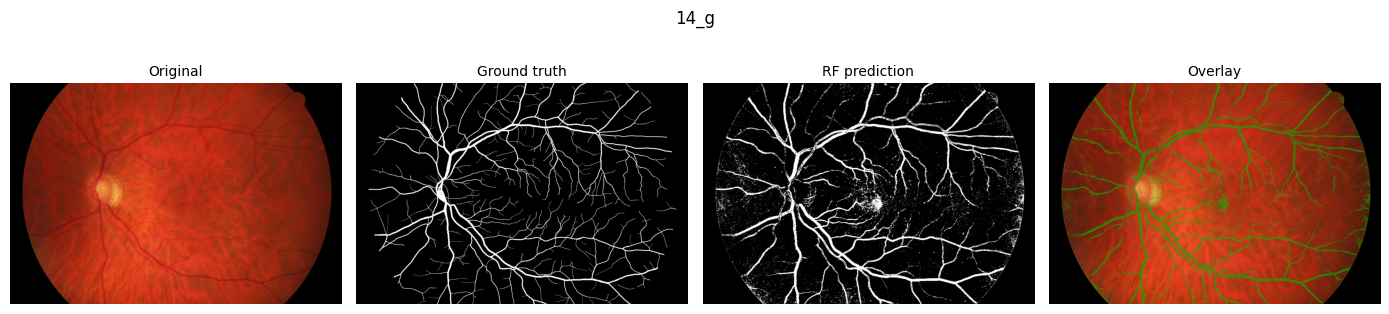

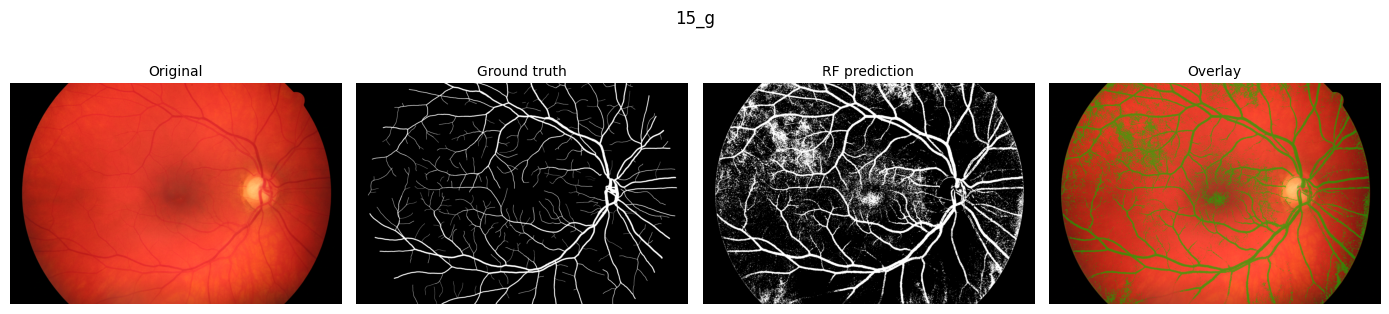

In [20]:
for image_id in TEST_IMAGES:
    img, gt, fv, pred = predictions[image_id]
    fig = visualize.compare_grid([
        ('Original', img),
        ('Ground truth', gt * 255),
        ('RF prediction', pred * 255),
        ('Overlay', visualize.overlay(img, pred, color=(0, 200, 0), alpha=0.6)),
    ], ncols=4, suptitle=image_id, figsize_per_panel=(3.5, 3.5))
    plt.show()

## 7. Zapis modelu i metryk

In [21]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / 'rf.joblib'
classical_ml.save_model(pipe, model_path)
print(f'Model: {model_path}  ({model_path.stat().st_size/1e6:.1f} MB)')

results_path = RESULTS_DIR / 'rf.json'
payload = {
    'method': 'random_forest_patches_5x5',
    'params': {
        'n_estimators': 100,
        'max_depth': None,
        'min_samples_leaf': 2,
        'patch_size': PATCH_SIZE,
        'n_train_images': N_TRAIN_IMAGES,
        'n_samples_per_image': N_SAMPLES_PER_IMAGE,
        'stride_predict': STRIDE,
        'sampling_strategy': 'auto (RandomUnderSampler → 0.5:0.5)',
        'grid_search_best_params': gs.best_params_,
        'grid_search_best_cv_score': float(gs.best_score_),
    },
    'test_images': list(TEST_IMAGES),
    'per_image': per_image,
    'aggregate': agg,
    'validation_holdout': {
        'accuracy':    acc,
        'sensitivity': sens,
        'specificity': spec,
        'g_mean':      g_mean,
    },
}
results_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False))
print(f'Metryki: {results_path}')

Model: /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/models/rf.joblib  (8.9 MB)
Metryki: /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/results/rf.json
